# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [1]:
from google.colab import files
uploaded = files.upload()

Saving tweet_sentiment_train.csv.zip to tweet_sentiment_train.csv.zip


In [60]:
import warnings
warnings.filterwarnings("ignore")
import sklearn as sk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer


In [5]:
raw_df = pd.read_csv("tweet_sentiment_train.csv.zip")

In [8]:
raw_df.shape

(27481, 4)

Маємо 27481 рядок і 4 колонки.

In [11]:
raw_df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [12]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [13]:
raw_df.isnull().sum()

,0
textID,0
text,1
selected_text,1
sentiment,0


In [14]:
raw_df = raw_df.dropna()

In [15]:
raw_df.isnull().sum()

,0
textID,0
text,0
selected_text,0
sentiment,0


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [16]:
# each class amount
raw_df['sentiment'].value_counts()

,count
sentiment,
neutral,11117
positive,8582
negative,7781


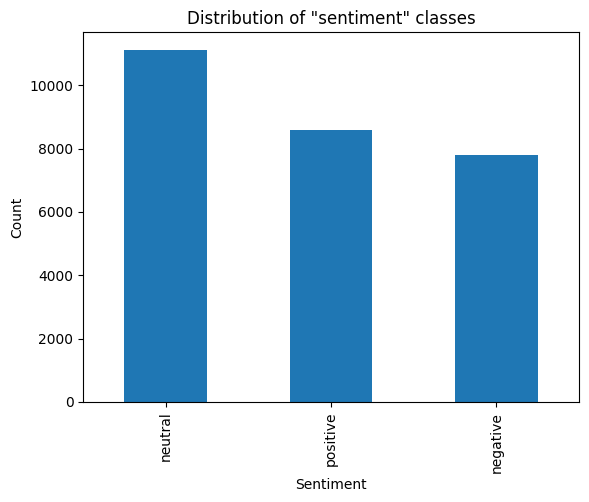

In [18]:
raw_df['sentiment'].value_counts().plot(kind='bar')

plt.title('Distribution of "sentiment" classes')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

Майже збалансовані класи.

In [21]:
# text length
raw_df['text_length'] = raw_df['text'].apply(len)

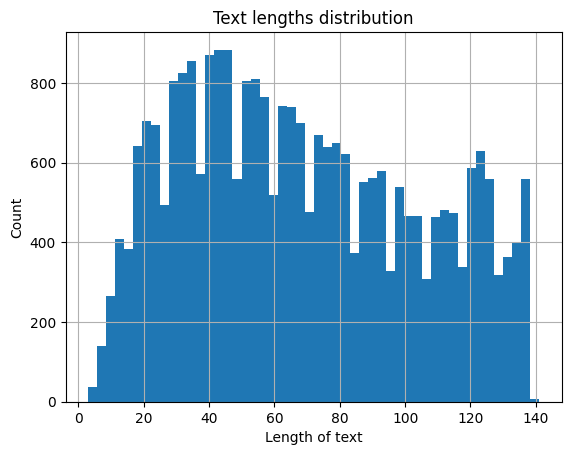

In [22]:
# histogram
raw_df['text_length'].hist(bins=50)
plt.title('Text lengths distribution')
plt.xlabel('Length of text')
plt.ylabel('Count')
plt.show()

Графік показав, що більшість текстів у датасеті середньої довжини: 30-80 символів. Також датасет містить малу кількість коротких текстів і більших за 80 небагато.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [42]:
# stopwords and stemmer
stop_words = stopwords.words('english')
stemmer = SnowballStemmer('english')


# clean text before tokenization
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    return text


# tokenization + stemming
def tokenize(text):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [stemmer.stem(word) for word in tokens]
    return tokens


# create Bag of Words vectorizer
vectorizer = CountVectorizer(
    preprocessor=clean_text,
    tokenizer=tokenize,
    token_pattern=None,
    lowercase=False,
    max_features=3000
)

# fit vocabulary and transform texts into vectors
X = vectorizer.fit_transform(raw_df['text'])

# target labels
y = raw_df['sentiment']

In [43]:
# display words from the vocabulary
vectorizer.get_feature_names_out()[:20]

array(['aah', 'abandon', 'abil', 'abl', 'absolut', 'abt', 'ac', 'academi',
       'accept', 'access', 'accid', 'accident', 'accomplish', 'accord',
       'account', 'ace', 'ach', 'ack', 'across', 'act'], dtype=object)

In [46]:
# sparse matrix info
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 165508 stored elements and shape (27480, 3000)>

In [45]:
# display the first text as a vector
X[0].toarray()

array([[0, 0, 0, ..., 0, 0, 0]])

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [48]:
# split the data
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# check shapes
print(X_train_bow.shape)
print(X_test_bow.shape)
print(y_train.shape)
print(y_test.shape)

(19236, 3000)
(8244, 3000)
(19236,)
(8244,)


In [50]:
# Logistic Regression
model = LogisticRegression(
    max_iter=1000,
    solver='sag'
)


model.fit(X_train_bow, y_train)

LogisticRegression(max_iter=1000, solver='sag')

In [51]:
# make predictions
train_preds = model.predict(X_train_bow)
test_preds = model.predict(X_test_bow)

In [52]:
# predict class proba
test_probs = model.predict_proba(X_test_bow)

In [53]:
# display probabilities
test_probs[:5]

array([[0.03372454, 0.18325098, 0.78302448],
       [0.11957073, 0.86712754, 0.01330173],
       [0.14480224, 0.8025222 , 0.05267557],
       [0.00909981, 0.36501093, 0.62588926],
       [0.19888748, 0.5959119 , 0.20520063]])

In [56]:
# evaluation metrics
print("Train Accuracy:", accuracy_score(y_train, train_preds))
print("Train F1:", f1_score(y_train, train_preds, average='weighted'))

print("Test Accuracy:", accuracy_score(y_test, test_preds))
print("Test F1:", f1_score(y_test, test_preds, average='weighted'))

Train Accuracy: 0.7966833021418174
Train F1: 0.7967817318099301
Test Accuracy: 0.6821931101407084
Test F1: 0.6818385308461568


Результат Логістичної Решресії показує, що модель гірше генералізує на нових даних.

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [59]:
# feature importance table
feature_importance = pd.Series(
    model.coef_[0],
    index=vectorizer.get_feature_names_out(),
    name='importance'
)

# sort by importance
feature_importance = feature_importance.sort_values(ascending=False)

# display top negative words
print("Top negative words:")
display(feature_importance.head(10))
print()
# display top positive words
print("Top positive words:")
display(feature_importance.tail(10))

Top negative words:


,importance
sad,2.571898
suck,2.396294
bore,2.358579
sorri,2.318674
hate,2.205637
miss,2.084300
disappoint,2.039280
fail,2.015227
shame,1.996923
worst,1.956649



Top positive words:


,importance
amaz,-1.633223
welcom,-1.653031
enjoy,-1.771809
thank,-1.900131
smile,-1.908028
congrat,-1.925837
love,-1.970573
cute,-2.033115
glad,-2.148259
awesom,-2.543557


Модель визначила емоційно забарвлені слова такі слова як "sad", "hate", "worst" та "fail" найбільше впливовими на визначення негативного настрою, тоді як слова "love", "smile", "enjoy" та "thank" більше впливають на визначення позитивного настрою. Отримані результати є логічними, адже емоційно виражені слова містять конкретну інформацію про настрій тексту та допомагають моделі краще розрізняти позитивні й негативні повідомлення.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [61]:
# TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    preprocessor=clean_text,
    tokenizer=tokenize,
    token_pattern=None,
    lowercase=False,
    max_features=3000
)

# transform texts into TF-IDF vectors
X_tfidf = tfidf_vectorizer.fit_transform(raw_df['text'])

# target labels
y = raw_df['sentiment']

In [62]:
# split into train and test sets
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.3,
    random_state=42
)

In [63]:
# Logistic Regression
model_tfidf = LogisticRegression(max_iter=1000)

model_tfidf.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [64]:
# make predictions
train_preds = model_tfidf.predict(X_train_tfidf)
test_preds = model_tfidf.predict(X_test_tfidf)

In [65]:
# evaluate model
print("Train Accuracy:",
      accuracy_score(y_train, train_preds))

print("Train F1:",
      f1_score(y_train, train_preds,
               average='weighted'))

print("Test Accuracy:",
      accuracy_score(y_test, test_preds))

print("Test F1:",
      f1_score(y_test, test_preds,
               average='weighted'))

Train Accuracy: 0.7664275317113745
Train F1: 0.7665054444717149
Test Accuracy: 0.6846191169335274
Test F1: 0.6838683150047079


In [66]:
# feature importance table
feature_importance = pd.Series(
    model_tfidf.coef_[0],
    index=tfidf_vectorizer.get_feature_names_out(),
    name='importance'
)

feature_importance=feature_importance.sort_values(
    ascending=False
)

print("Top negative words:")
display(feature_importance.head(10))

print("Top positive words:")
display(feature_importance.tail(10))

Top negative words:


,importance
sad,4.946217
miss,4.838846
sorri,4.252557
suck,4.209657
hate,4.062186
bore,3.865011
fail,3.471863
sick,3.307626
stupid,3.263825
hurt,3.128918


Top positive words:


,importance
better,-2.163636
enjoy,-2.309315
cute,-2.355718
nice,-2.520261
glad,-2.623463
great,-2.835816
hope,-3.062632
awesom,-3.398997
thank,-3.641184
love,-4.424976


TF-IDF показав кращу якість класифікації порівняно з BОW, оскільки враховує не лише частоту слова у тексті, а й його важливість серед усіх документів. Це дозволяє зменшити вплив дуже частих слів та виділити більш інформативні токени. Для фінальної реалізації доцільніше використовувати TF-IDF, оскільки він краще відображає значущість слів.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [67]:
# classification errors
errors = pd.DataFrame({
    'text':raw_df.loc[y_test.index,'text'],
    'true':y_test,
    'predicted':test_preds
})

errors=errors[
    errors['true']!=errors['predicted']
]

errors.head(10)

,text,true,predicted
10414,--of them kinda turns me off of it all. And ...,negative,neutral
6718,At work... What a miserable day,negative,neutral
2831,I wish I had company,negative,positive
16793,Intel gfx driver situation much better with re...,negative,neutral
4891,xD hello that`s an important date!,positive,neutral
10882,. Well gotdamn girl!!! I dont know what else!!...,neutral,negative
17382,FYI no internets until THURSTAG!!!! after satu...,positive,negative
4098,**** being broke on the day Guitar Hero Metall...,negative,neutral
20028,Yep! Tail between legs!,negative,neutral
19671,Avoided cinder blocks! Safe in NY area.. But D...,neutral,negative


Під час аналізу помилок видно, що модель найчастіше помиляється на коротких повідомленнях, неоднозначних текстах та реченнях без явно виражених емоційних слів.
Також помилки виникають у випадках змішаних емоцій, неформального стилю, скорочень.
Для покращення якості класифікації можна використати біграми/триграми, збільшити кількість ознак, застосувати сучасні методи Word2Vec чи BERT.

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model